# Cointegration and Hurst Exponent

This notebook covers five topics:
1. Engle-Granger cointegration test
2. US stock cointegration examples
3. Vasicek (Ornstein-Uhlenbeck) process simulation
4. Vasicek parameter estimation and verification
5. Hurst exponent estimation with US stock examples

---
## 1. Engle-Granger Cointegration Test

Given two time series $X_t$ and $Y_t$, perform OLS regression:

$$X_t = c + \alpha Y_t + \epsilon_t$$

The residual series is:

$$\epsilon_t = X_t - c - \alpha Y_t$$

$X_t$ and $Y_t$ are **cointegrated** if and only if $\epsilon_t$ is stationary.  
We check stationarity using the **Augmented Dickey-Fuller (ADF) test**.  
More negative ADF statistic $\Rightarrow$ stronger evidence of cointegration.

Estimated alpha: 1.2067
ADF statistic:   -20.9024
p-value:         0.0000
  Critical value (1%): -3.4435
  Critical value (5%): -2.8673
  Critical value (10%): -2.5699


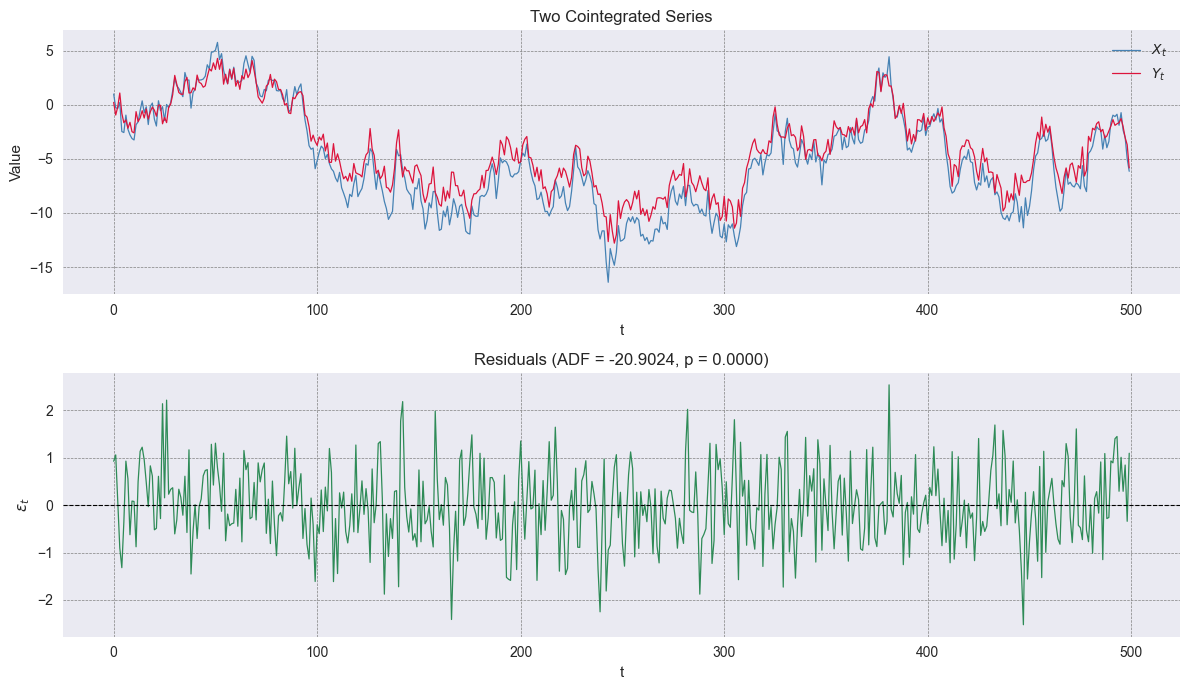

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.stattools import adfuller

plt.style.use("seaborn-v0_8")


def engle_granger_test(x, y):
    y_with_const = add_constant(y)
    result = OLS(x, y_with_const).fit()
    alpha = result.params[1]
    residuals = result.resid
    adf_stat, p_value, used_lag, n_obs, critical_values, _ = adfuller(residuals)
    return residuals, alpha, adf_stat, p_value, critical_values


# Demo with synthetic cointegrated series
rng = np.random.default_rng(42)
n = 500
common_trend = np.cumsum(rng.normal(0, 1, n))
x = common_trend + rng.normal(0, 0.5, n)
y = 0.8 * common_trend + rng.normal(0, 0.5, n)

residuals, alpha, adf_stat, p_value, crit = engle_granger_test(x, y)

print(f"Estimated alpha: {alpha:.4f}")
print(f"ADF statistic:   {adf_stat:.4f}")
print(f"p-value:         {p_value:.4f}")
for level, val in crit.items():
    print(f"  Critical value ({level}): {val:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(x, color="steelblue", linewidth=0.9, label="$X_t$")
axes[0].plot(y, color="crimson", linewidth=0.9, label="$Y_t$")
axes[0].set(title="Two Cointegrated Series", xlabel="t", ylabel="Value")
axes[0].legend()
axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

axes[1].plot(residuals, color="seagreen", linewidth=0.9)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set(
    title=f"Residuals (ADF = {adf_stat:.4f}, p = {p_value:.4f})",
    xlabel="t",
    ylabel=r"$\epsilon_t$",
)
axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")

plt.tight_layout()
plt.show()

---
## 2. US Stock Cointegration Examples

We apply the Engle-Granger test to two US stock pairs with plausible economic linkage:
- **KO vs PEP** (beverages sector)
- **XOM vs CVX** (energy sector)




KO vs PEP
  alpha = -0.2127, ADF = -2.4486, p-value = 0.1285
  Critical value (1%): -3.4435
  Critical value (5%): -2.8673
  Critical value (10%): -2.5699



XOM vs CVX
  alpha = 0.5070, ADF = -2.0035, p-value = 0.2850
  Critical value (1%): -3.4435
  Critical value (5%): -2.8673
  Critical value (10%): -2.5699


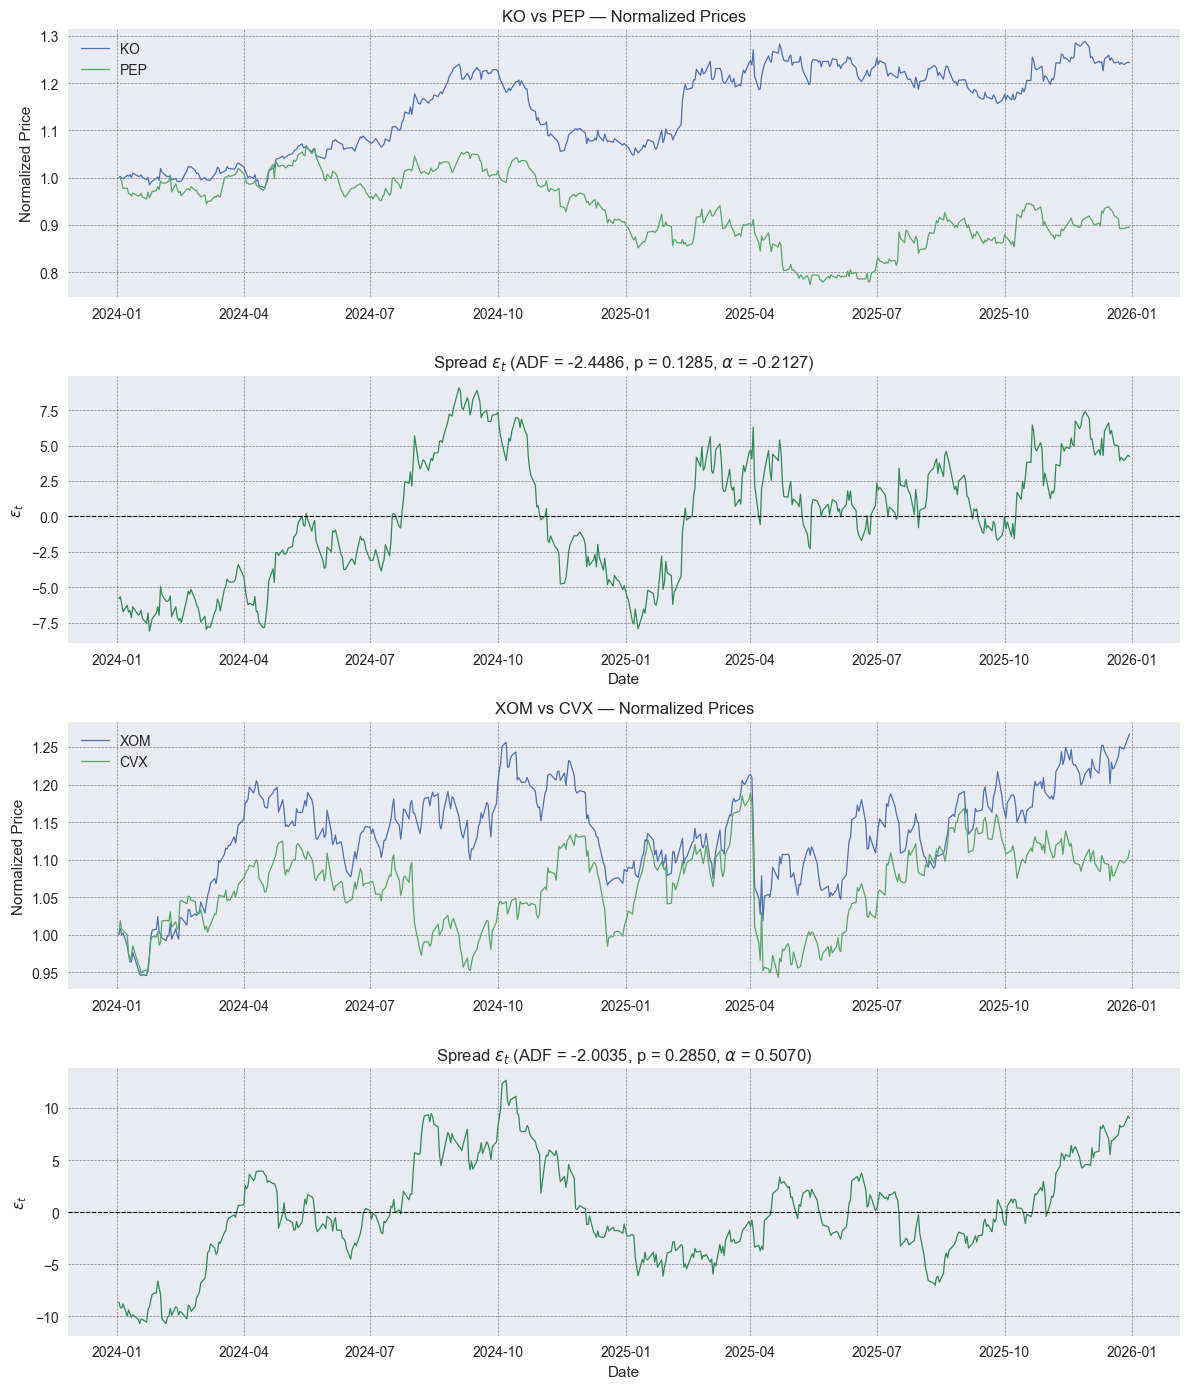

In [2]:
import yfinance as yf


def fetch_close_prices(ticker, start, end):
    data = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    return data["Close"].squeeze()


def analyze_pair(ticker_a, ticker_b, start, end, ax_prices, ax_spread):
    prices_a = fetch_close_prices(ticker_a, start, end)
    prices_b = fetch_close_prices(ticker_b, start, end)
    common = prices_a.index.intersection(prices_b.index)
    pa = prices_a.loc[common].values
    pb = prices_b.loc[common].values
    dates = prices_a.loc[common].index

    residuals, alpha, adf_stat, p_value, crit = engle_granger_test(pa, pb)

    norm_a = pa / pa[0]
    norm_b = pb / pb[0]

    ax_prices.plot(dates, norm_a, linewidth=0.9, label=ticker_a)
    ax_prices.plot(dates, norm_b, linewidth=0.9, label=ticker_b)
    ax_prices.set(title=f"{ticker_a} vs {ticker_b} — Normalized Prices", ylabel="Normalized Price")
    ax_prices.legend()
    ax_prices.grid(True, linestyle="--", linewidth=0.5, color="gray")

    ax_spread.plot(dates, residuals, color="seagreen", linewidth=0.9)
    ax_spread.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax_spread.set(
        title=rf"Spread $\epsilon_t$ (ADF = {adf_stat:.4f}, p = {p_value:.4f}, $\alpha$ = {alpha:.4f})",
        xlabel="Date",
        ylabel=r"$\epsilon_t$",
    )
    ax_spread.grid(True, linestyle="--", linewidth=0.5, color="gray")

    print(f"\n{ticker_a} vs {ticker_b}")
    print(f"  alpha = {alpha:.4f}, ADF = {adf_stat:.4f}, p-value = {p_value:.4f}")
    for level, val in crit.items():
        print(f"  Critical value ({level}): {val:.4f}")


start, end = "2024-01-01", "2025-12-31"

fig, axes = plt.subplots(4, 1, figsize=(12, 14))
analyze_pair("KO", "PEP", start, end, axes[0], axes[1])
analyze_pair("XOM", "CVX", start, end, axes[2], axes[3])
plt.tight_layout()
plt.show()

---
## 3. Vasicek Process (Ornstein-Uhlenbeck) Simulation

The Vasicek process satisfies the stochastic differential equation:

$$dV_t = \alpha(\mu - V_t)\,dt + \sigma\,dW_t$$

where $W_t$ is a Brownian motion. The process captures **mean reversion**: $V_t$ fluctuates but reverts to $\mu$ at speed $\alpha$.

**Euler-Maruyama discretization:**

$$V_{t+\Delta t} = V_t + \alpha(\mu - V_t)\Delta t + \sigma\sqrt{\Delta t}\,Z_t, \quad Z_t \sim N(0,1)$$

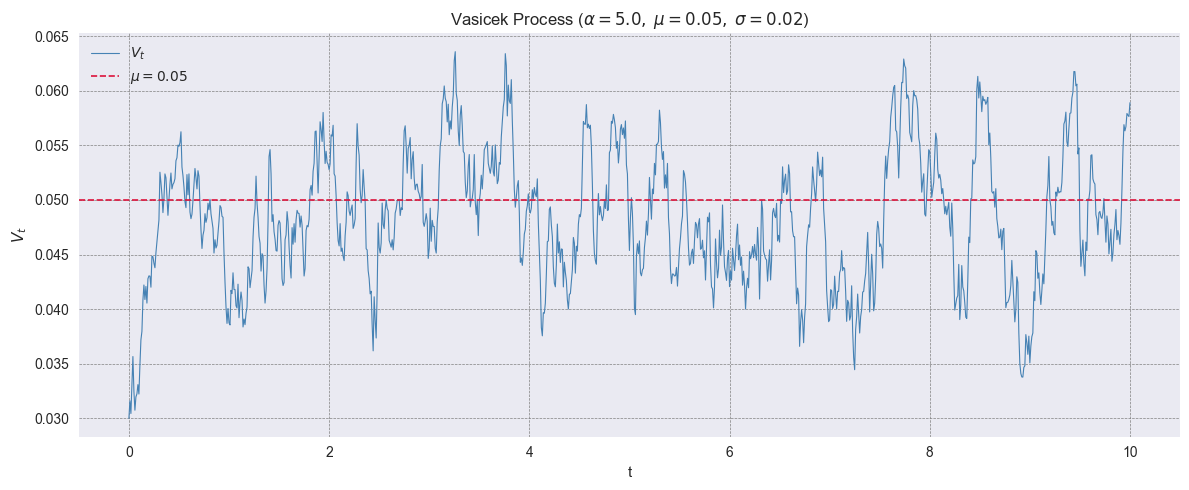

In [3]:
def simulate_vasicek(alpha, mu, sigma, v0, T, dt, seed):
    rng = np.random.default_rng(seed)
    n_steps = int(T / dt)
    t = np.linspace(0, T, n_steps + 1)
    v = np.zeros(n_steps + 1)
    v[0] = v0
    sqrt_dt = np.sqrt(dt)
    z = rng.normal(size=n_steps)
    for i in range(n_steps):
        v[i + 1] = v[i] + alpha * (mu - v[i]) * dt + sigma * sqrt_dt * z[i]
    return t, v


alpha_sim = 5.0
mu_sim = 0.05
sigma_sim = 0.02
v0 = 0.03
T = 10.0
dt = 0.01

t, v = simulate_vasicek(alpha_sim, mu_sim, sigma_sim, v0, T, dt, seed=42)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, v, color="steelblue", linewidth=0.8, label="$V_t$")
ax.axhline(mu_sim, color="crimson", linestyle="--", linewidth=1.2,
           label=rf"$\mu = {mu_sim}$")
ax.set(
    title=rf"Vasicek Process ($\alpha={alpha_sim},\;\mu={mu_sim},\;\sigma={sigma_sim}$)",
    xlabel="t",
    ylabel="$V_t$",
)
ax.legend()
ax.grid(True, linestyle="--", linewidth=0.5, color="gray")
plt.tight_layout()
plt.show()

---
## 4. Vasicek Parameter Estimation

Given observed data from a Vasicek process, we estimate parameters using an **AR(1) regression** (Herlemont).

Fit the discrete model:

$$x_t - x_{t-1} = a + b\,x_{t-1} + \varepsilon_t$$

Then recover continuous-time parameters:

$$\mu = -\frac{a}{b}, \qquad \alpha = -\frac{\ln(1 + b)}{\Delta t}$$

$$\sigma = \sigma_\varepsilon \sqrt{\frac{-2\ln(1+b) / \Delta t}{1 - (1+b)^2}}$$

**Verification:** simulate with known parameters, then estimate and compare.

Parameter Estimation (Vasicek / Ornstein-Uhlenbeck)
  Param          True  Estimated
  alpha        5.0000     4.8567
  mu           0.0500     0.0492
  sigma        0.0200     0.0205


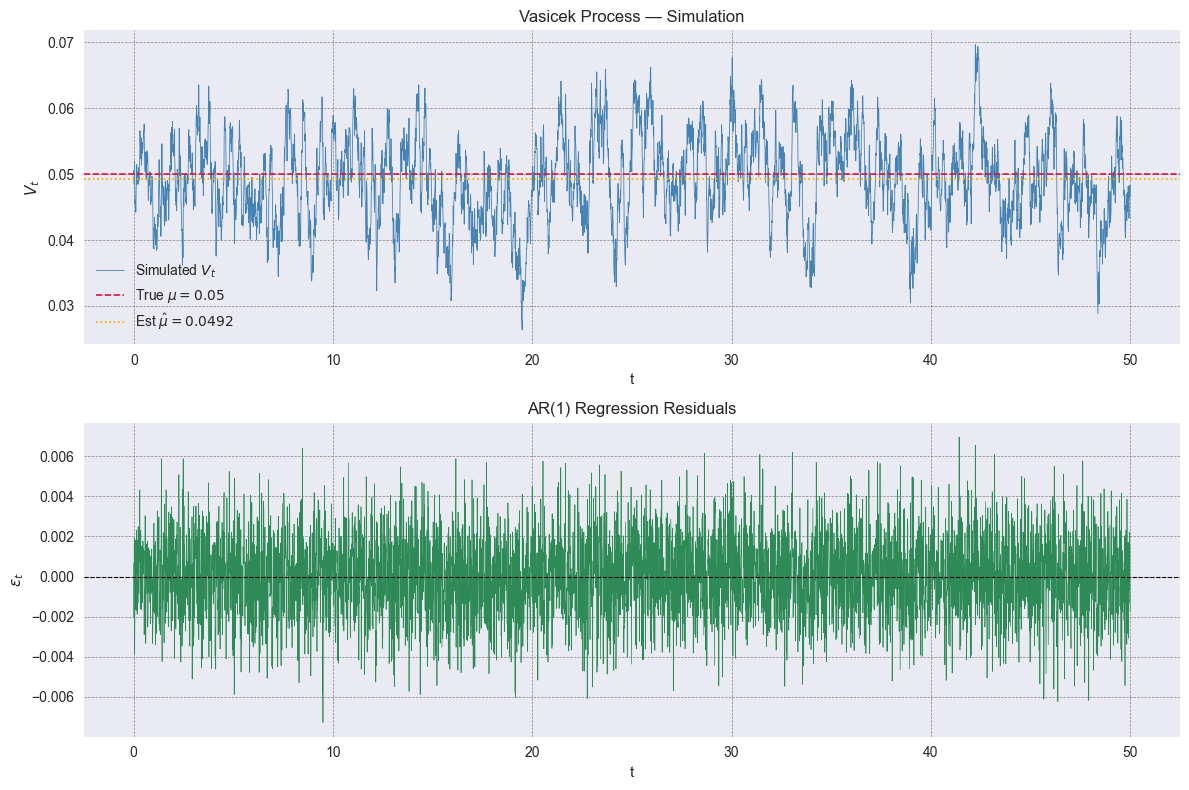

In [4]:
def estimate_vasicek(v, dt):
    dx = np.diff(v)
    x_lag = v[:-1]
    x_lag_const = add_constant(x_lag)
    result = OLS(dx, x_lag_const).fit()
    a, b = result.params
    sigma_eps = np.std(result.resid, ddof=2)

    # Herlemont eqs 25-26
    mu_est = -a / b
    alpha_est = -np.log(1 + b) / dt
    sigma_est = sigma_eps * np.sqrt(-2 * np.log(1 + b) / (dt * (1 - (1 + b) ** 2)))
    return mu_est, alpha_est, sigma_est


# True parameters
alpha_true = 5.0
mu_true = 0.05
sigma_true = 0.02

t_est, v_est = simulate_vasicek(alpha_true, mu_true, sigma_true, v0=mu_true, T=50.0, dt=0.01, seed=42)
mu_est, alpha_est, sigma_est = estimate_vasicek(v_est, dt=0.01)

print("Parameter Estimation (Vasicek / Ornstein-Uhlenbeck)")
print(f"  {'Param':<8} {'True':>10} {'Estimated':>10}")
print(f"  {'alpha':<8} {alpha_true:>10.4f} {alpha_est:>10.4f}")
print(f"  {'mu':<8} {mu_true:>10.4f} {mu_est:>10.4f}")
print(f"  {'sigma':<8} {sigma_true:>10.4f} {sigma_est:>10.4f}")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(t_est, v_est, color="steelblue", linewidth=0.6, label="Simulated $V_t$")
axes[0].axhline(mu_true, color="crimson", linestyle="--", linewidth=1.2,
                label=rf"True $\mu = {mu_true}$")
axes[0].axhline(mu_est, color="orange", linestyle=":", linewidth=1.2,
                label=rf"Est $\hat{{\mu}} = {mu_est:.4f}$")
axes[0].set(title="Vasicek Process — Simulation", xlabel="t", ylabel="$V_t$")
axes[0].legend()
axes[0].grid(True, linestyle="--", linewidth=0.5, color="gray")

dx = np.diff(v_est)
x_lag_const = add_constant(v_est[:-1])
resid = OLS(dx, x_lag_const).fit().resid
axes[1].plot(t_est[1:], resid, color="seagreen", linewidth=0.5)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set(title="AR(1) Regression Residuals", xlabel="t", ylabel=r"$\varepsilon_t$")
axes[1].grid(True, linestyle="--", linewidth=0.5, color="gray")

plt.tight_layout()
plt.show()

---
## 5. Hurst Exponent

A **fractional Brownian motion** $W^H(t)$ generalizes standard Brownian motion with:

$$\text{Cov}(W^H(t), W^H(u)) = \tfrac{1}{2}\bigl(|t|^{2H} + |u|^{2H} - |t-u|^{2H}\bigr)$$

where $0 < H < 1$ is the **Hurst exponent**.

| $H$ | Behavior | Increments |
|-----|----------|------------|
| $H = 0.5$ | Brownian motion (random walk) | Independent |
| $H > 0.5$ | **Trending** | Positively correlated |
| $H < 0.5$ | **Mean-reverting** | Negatively correlated |

We estimate $H$ for three US stocks using rescaled range (R/S) analysis.

AAPL: H = 0.6029 => Trending


JNJ: H = 0.5356 => Random Walk
GLD: H = 0.8020 => Trending


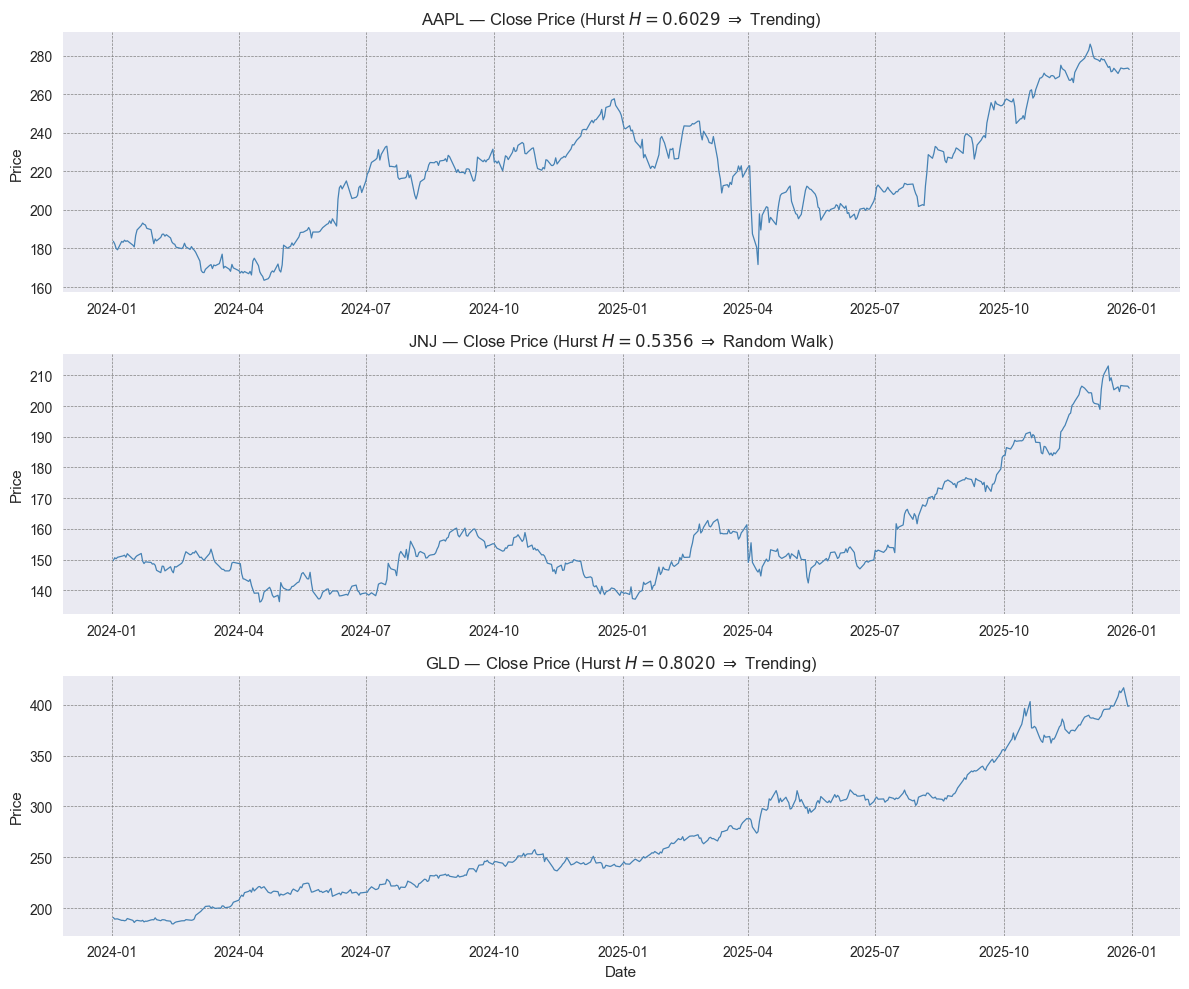

In [5]:
from hurst import compute_Hc


def estimate_hurst(prices):
    H, c, data = compute_Hc(prices.values, kind="price", simplified=True)
    return H


tickers = ["AAPL", "JNJ", "GLD"]
start, end = "2024-01-01", "2025-12-31"

fig, axes = plt.subplots(len(tickers), 1, figsize=(12, 10))

for ax, ticker in zip(axes, tickers):
    prices = fetch_close_prices(ticker, start, end)
    H = estimate_hurst(prices)

    if H > 0.55:
        behavior = "Trending"
    elif H < 0.45:
        behavior = "Mean-Reverting"
    else:
        behavior = "Random Walk"

    print(f"{ticker}: H = {H:.4f} => {behavior}")

    ax.plot(prices.index, prices.values, color="steelblue", linewidth=0.9)
    ax.set(
        title=rf"{ticker} — Close Price (Hurst $H = {H:.4f}$ $\Rightarrow$ {behavior})",
        ylabel="Price",
    )
    ax.grid(True, linestyle="--", linewidth=0.5, color="gray")

axes[-1].set(xlabel="Date")
plt.tight_layout()
plt.show()